In [17]:
import numpy as np
from scipy import ndimage
import matplotlib.pyplot as plt
import cv2
import time
import os

plt.rcParams['figure.figsize'] = (12, 8)

# ====================== Canny Edge Detection Baseline ======================

def rgb2gray(img):
    """RGB转灰度"""
    if len(img.shape) == 3:
        return np.dot(img[...,:3], [0.299, 0.587, 0.144])
    return img.astype(np.float32)

def gaussian_blur(img, sigma=1.4):
    """高斯滤波"""
    return ndimage.gaussian_filter(img, sigma=sigma)

def sobel_gradients(img):
    """Sobel梯度计算"""
    Kx = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float32)
    Ky = np.array([[1, 2, 1], [0, 0, 0], [-1, -2, -1]], dtype=np.float32)
    
    Gx = ndimage.convolve(img, Kx)
    Gy = ndimage.convolve(img, Ky)
    
    magnitude = np.hypot(Gx, Gy)
    angle = np.arctan2(Gy, Gx) * (180 / np.pi) % 180
    
    return magnitude, angle

def non_max_suppression(magnitude, angle):
    """非极大值抑制（核心手写部分）"""
    h, w = magnitude.shape
    suppressed = np.zeros((h, w), dtype=np.float32)
    
    for i in range(1, h-1):
        for j in range(1, w-1):
            ang = angle[i, j]
            
            if (0 <= ang < 22.5) or (157.5 <= ang <= 180):
                n1, n2 = magnitude[i, j-1], magnitude[i, j+1]
            elif 22.5 <= ang < 67.5:
                n1, n2 = magnitude[i-1, j-1], magnitude[i+1, j+1]
            elif 67.5 <= ang < 112.5:
                n1, n2 = magnitude[i-1, j], magnitude[i+1, j]
            else:
                n1, n2 = magnitude[i-1, j+1], magnitude[i+1, j-1]
            
            if magnitude[i, j] >= n1 and magnitude[i, j] >= n2:
                suppressed[i, j] = magnitude[i, j]
    return suppressed

def double_threshold_hysteresis(suppressed, low_th=50, high_th=150):
    """双阈值 + 滞后阈值"""
    strong = 255
    edges = np.zeros_like(suppressed, dtype=np.uint8)
    strong_edges = (suppressed >= high_th)
    weak_edges = (suppressed >= low_th) & (suppressed < high_th)
    
    edges[strong_edges] = strong
    
    # 使用连通组件连接弱边缘
    from scipy import ndimage as ndi
    labeled, _ = ndi.label(weak_edges)
    for label in range(1, labeled.max() + 1):
        component = (labeled == label)
        if np.any(component & strong_edges):
            edges[component] = strong
    
    return edges

def canny_edge_detector(image_path, low_th=50, high_th=150, sigma=1.4):
    """完整 Canny 流程"""
    img = cv2.imread(image_path)
    if img is None:
        raise FileNotFoundError(f"Cannot read image: {image_path}")
    
    gray = rgb2gray(img)
    blurred = gaussian_blur(gray, sigma)
    magnitude, angle = sobel_gradients(blurred)
    suppressed = non_max_suppression(magnitude, angle)
    edges = double_threshold_hysteresis(suppressed, low_th, high_th)
    
    return edges, blurred, magnitude, suppressed

print("✅ Canny Baseline 函数定义完成！")

✅ Canny Baseline 函数定义完成！


=== Canny Edge Detection 测试 ===
正在处理图片: ../data/test.jpg


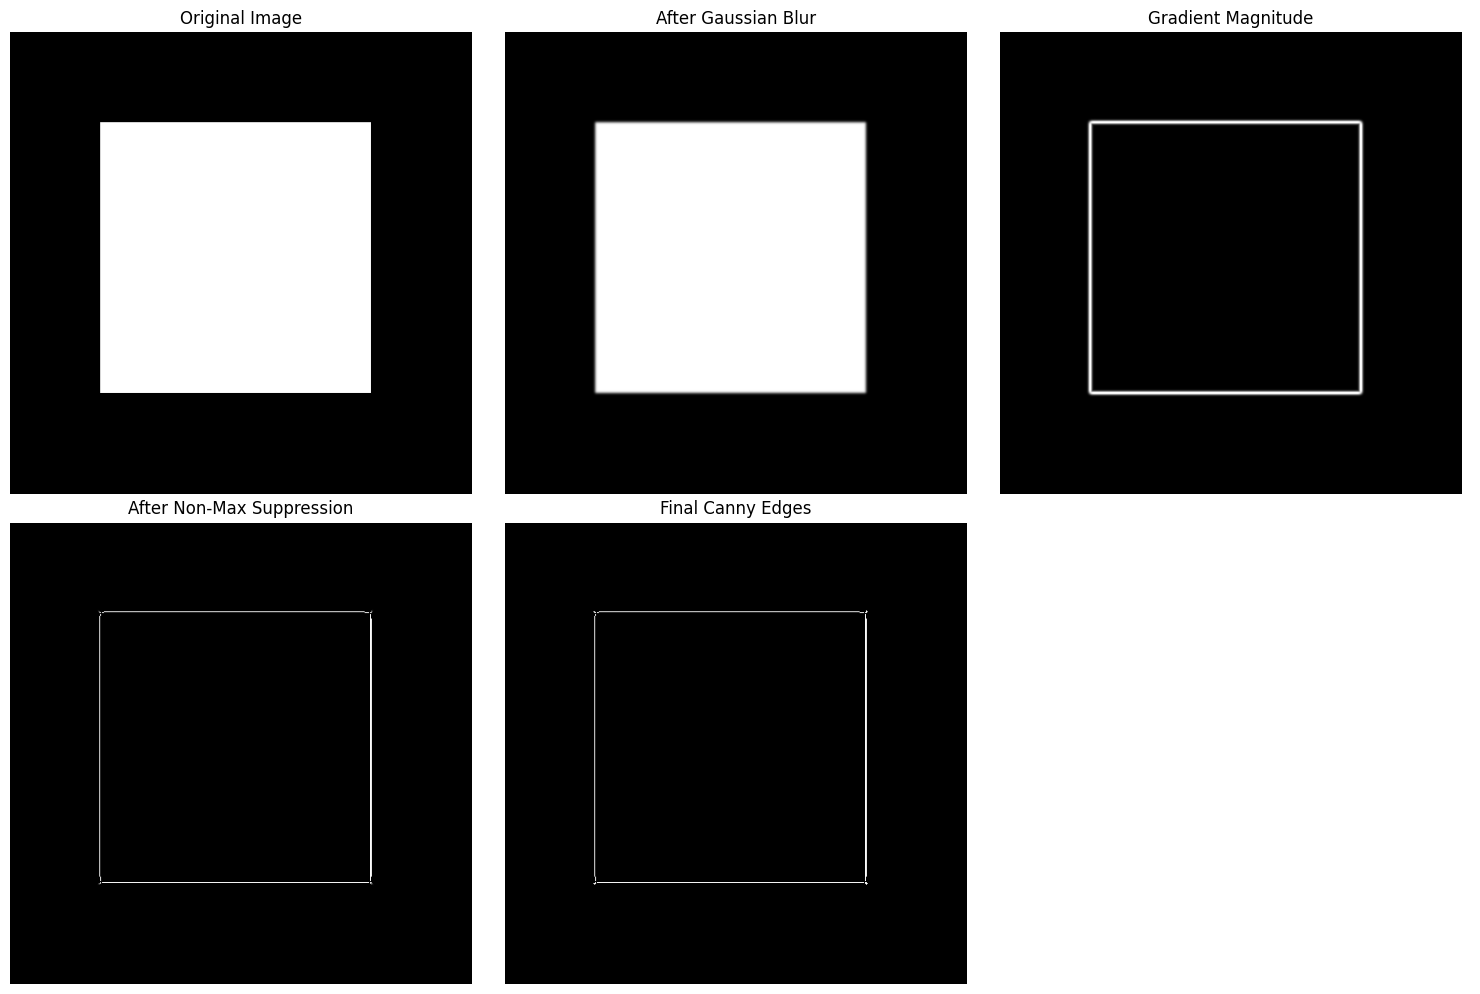

✅ 测试完成！你可以把自己的真实图片放到 data/ 文件夹中测试


In [18]:
# ====================== 改进的测试与可视化 ======================

def test_canny(image_filename="test.jpg", low_th=50, high_th=150, sigma=1.4):
    image_path = f"../data/{image_filename}"
    
    if not os.path.exists(image_path):
        print(f"⚠️ 未找到 {image_filename}，使用默认测试图像...")
        # 生成更清晰的测试图像（带边缘的正方形）
        test_img = np.zeros((512, 512, 3), dtype=np.uint8)
        cv2.rectangle(test_img, (100, 100), (412, 412), (255, 255, 255), -1)
        cv2.rectangle(test_img, (150, 150), (362, 362), (0, 0, 0), -1)
        cv2.imwrite(image_path, test_img)
        print(f"✅ 已生成测试图片: {image_path}")
    
    print(f"正在处理图片: {image_path}")
    edges, blurred, magnitude, suppressed = canny_edge_detector(image_path, low_th, high_th, sigma)
    
    # 显示所有中间结果
    fig, axs = plt.subplots(2, 3, figsize=(15, 10))
    titles = ["Original Image", "After Gaussian Blur", "Gradient Magnitude", 
              "After Non-Max Suppression", "Final Canny Edges", ""]
    images = [cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB), 
              blurred, magnitude, suppressed, edges, None]
    
    for i, ax in enumerate(axs.flat):
        if i < 5:
            if i == 0:
                ax.imshow(images[i])
            else:
                ax.imshow(images[i], cmap='gray')
            ax.set_title(titles[i])
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return edges

# 运行测试
print("=== Canny Edge Detection 测试 ===")
edges = test_canny("test.jpg", low_th=30, high_th=100)
print("✅ 测试完成！你可以把自己的真实图片放到 data/ 文件夹中测试")

In [19]:
# ====================== 性能测试 (Benchmark) ======================

def benchmark_canny(image_filename="test.jpg", runs=10):
    image_path = f"../data/{image_filename}"
    times = []
    
    print(f"开始性能测试 ({runs} 次运行)...")
    for i in range(runs):
        start = time.perf_counter()
        edges, _, _, _ = canny_edge_detector(image_path)
        end = time.perf_counter()
        times.append(end - start)
    
    mean_time = np.mean(times)
    std_time = np.std(times)
    
    print(f"✅ 平均执行时间: {mean_time:.4f} ± {std_time:.4f} 秒")
    print(f"   每秒可处理图片数量: {1/mean_time:.2f} FPS")
    
    return mean_time, edges

# 使用示例
mean_time, edges = benchmark_canny(runs=5)

开始性能测试 (5 次运行)...
✅ 平均执行时间: 0.3023 ± 0.0116 秒
   每秒可处理图片数量: 3.31 FPS


正在测试图片: IMG_6860.JPG
正在处理图片: ../data/IMG_6860.JPG


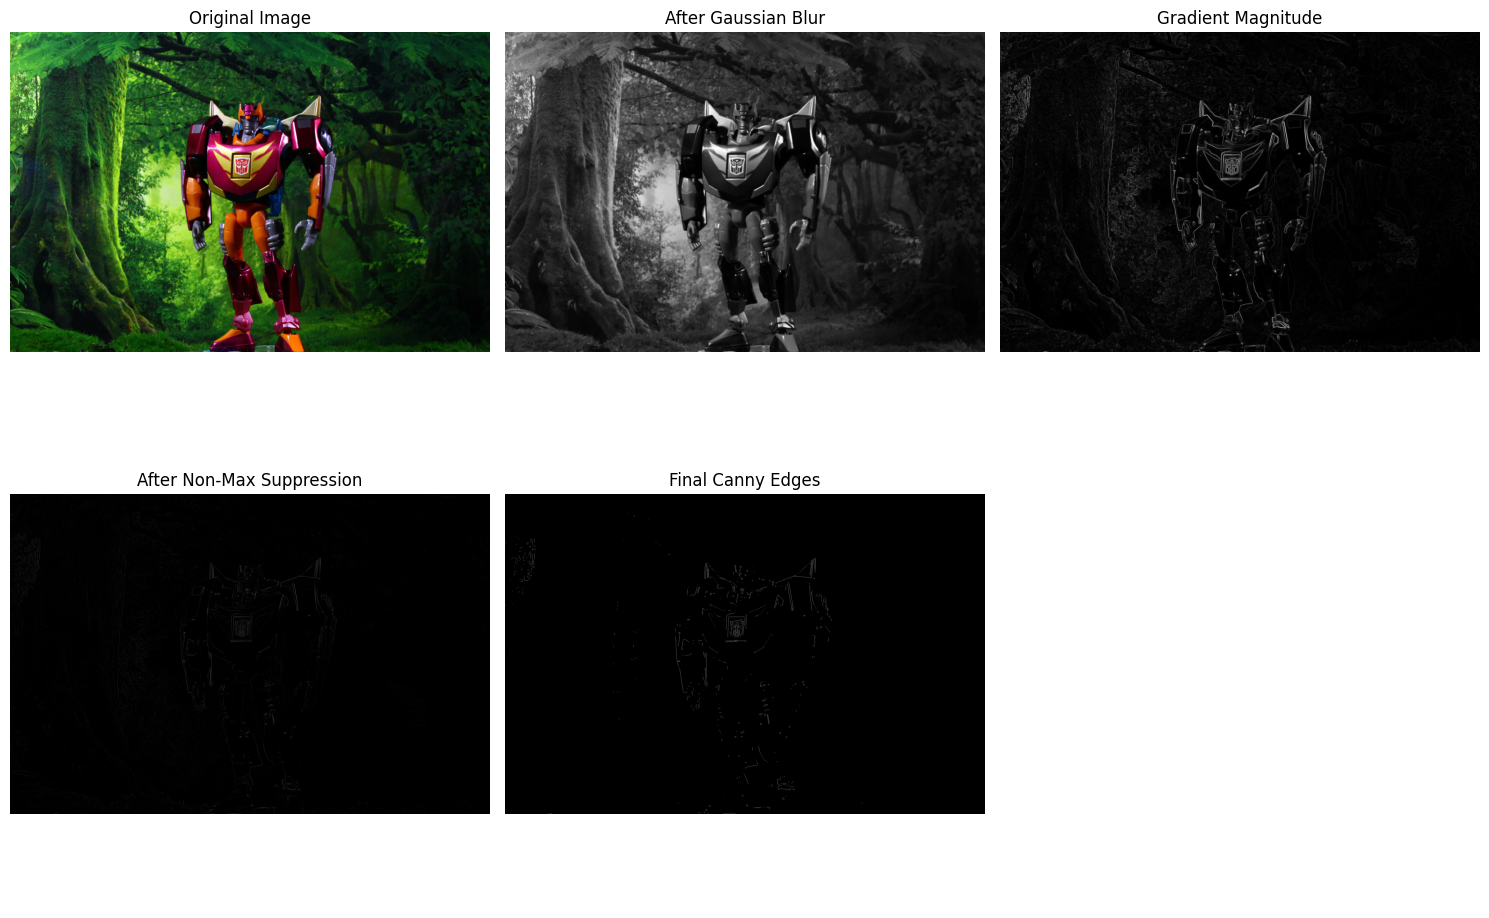


=== 性能测试 ===
开始性能测试 (5 次运行)...
✅ 平均执行时间: 323.0056 ± 1.5035 秒
   每秒可处理图片数量: 0.00 FPS


In [20]:
# ====================== 最终测试（推荐使用真实图片） ======================

# 把你的真实图片放到 data/ 文件夹，然后修改文件名测试
image_name = "IMG_6860.JPG"        # ← 这里改成你的真实图片文件名

print(f"正在测试图片: {image_name}")
edges = test_canny(image_name, low_th=50, high_th=150, sigma=1.4)

# 额外显示性能
print("\n=== 性能测试 ===")
mean_time, _ = benchmark_canny(image_name, runs=5)

In [21]:
# ====================== 保存图像用于报告 ======================

def save_results(image_name="test.jpg"):
    image_path = f"../data/{image_name}"
    edges, blurred, magnitude, suppressed = canny_edge_detector(image_path)
    
    orig = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
    
    # 保存关键图片到 report 文件夹
    os.makedirs("../report", exist_ok=True)
    
    plt.imsave("../report/01_original.png", orig)
    plt.imsave("../report/02_blurred.png", blurred, cmap='gray')
    plt.imsave("../report/03_magnitude.png", magnitude, cmap='gray')
    plt.imsave("../report/04_suppressed.png", suppressed, cmap='gray')
    plt.imsave("../report/05_final_edges.png", edges, cmap='gray')
    
    print("✅ 已保存 5 张图片到 report/ 文件夹，供报告使用")

save_results(image_name)

✅ 已保存 5 张图片到 report/ 文件夹，供报告使用
